# Detailed Evaluation

This notebook shows how to produce some tables and plots for analysing results. This is meant as a starting point, because eah game will require a custom evaluation depending on its metrics and experiments.

This notebook uses the output files of evaluation/bencheval.py. Run that first.

In [4]:
import sys
sys.path.append('..')
import re

from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import ListedColormap
from matplotlib.patches import Polygon

import evaluation.evalutils as utils
from evaluation.makingtables import build_dispersion_table
import clemgame.metrics as clemmetrics

In [5]:
# Prep Data

RAW_PATH = Path('../results/raw.csv')
raw_df = pd.read_csv(RAW_PATH, index_col=0)

game_df = raw_df[raw_df.game == 'grounding']
game_fsc_df = game_df[game_df.model == 'mock-t0.0--mock-t0.0']

stats_df = build_dispersion_table(['game', 'model', 'metric'], game_df) # or raw_df for results for all games
stats_fsc_df = build_dispersion_table(['game', 'model', 'metric'], game_fsc_df) # or raw_df for results for all games

detailed_stats_df = build_dispersion_table(['game', 'model', 'experiment', 'metric'], game_df) # or raw_df for results for all games
detailed_stats_fsc_df = build_dispersion_table(['game', 'model', 'experiment', 'metric'], game_fsc_df) # or raw_df for results for all games

stats_df.to_csv('../results/stats.csv')
detailed_stats_df.to_csv('../results/detailed_stats.csv')
detailed_stats_fsc_df.to_csv('../results/detailed_stats_fsc.csv')

game_df

,game,model,experiment,episode,metric,value
0,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Aborted,0.0
1,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Request Count,13.0
2,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Parsed Request Count,13.0
3,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Violated Request Count,0.0
4,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Request Success Ratio,1.0
...,...,...,...,...,...,...
865,grounding,mock-t0.0--mock-t0.0,2_long,episode_5,Played,1.0
866,grounding,mock-t0.0--mock-t0.0,2_long,episode_6,Played,1.0
867,grounding,mock-t0.0--mock-t0.0,2_long,episode_7,Played,1.0
868,grounding,mock-t0.0--mock-t0.0,2_long,episode_8,Played,1.0


C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['experiment'] = metric_df['experiment'].astype(str)
C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)


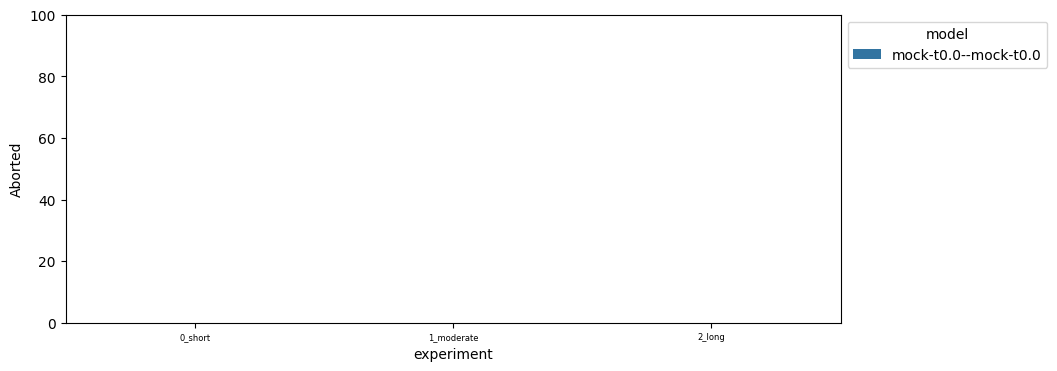

C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['experiment'] = metric_df['experiment'].astype(str)
C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)


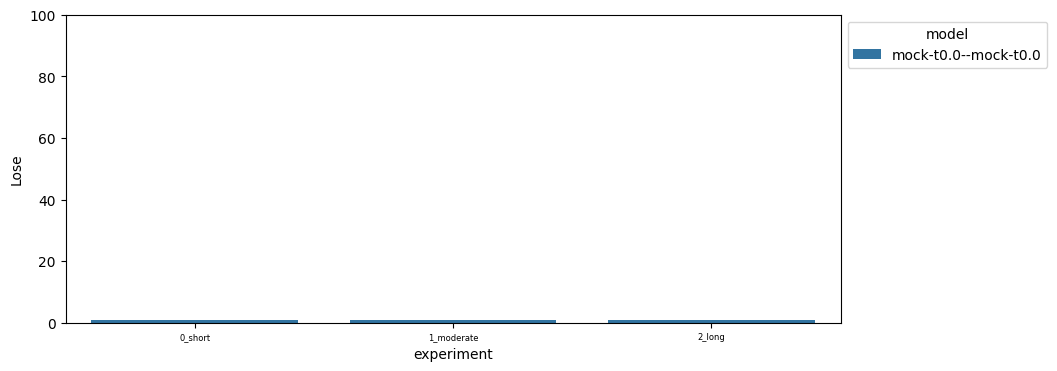

C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['experiment'] = metric_df['experiment'].astype(str)
C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)


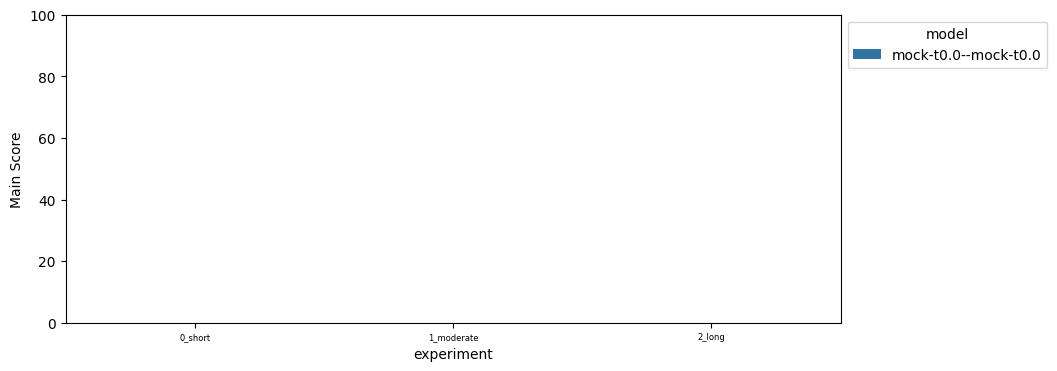

C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['experiment'] = metric_df['experiment'].astype(str)
C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)


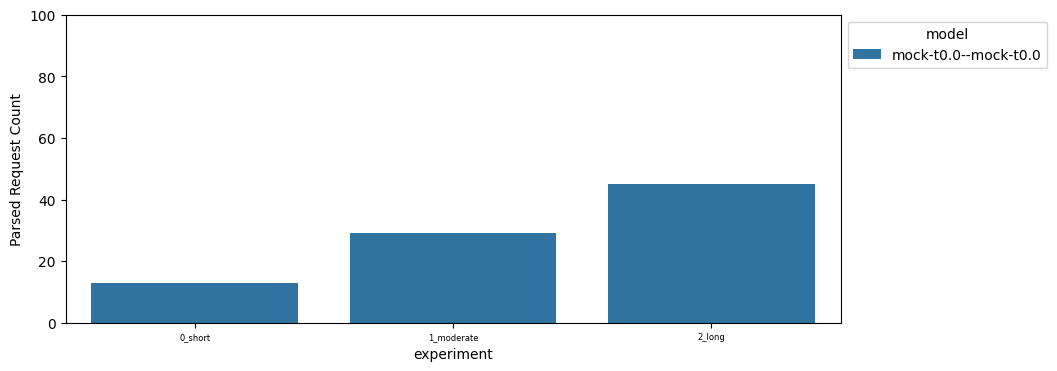

C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['experiment'] = metric_df['experiment'].astype(str)
C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)


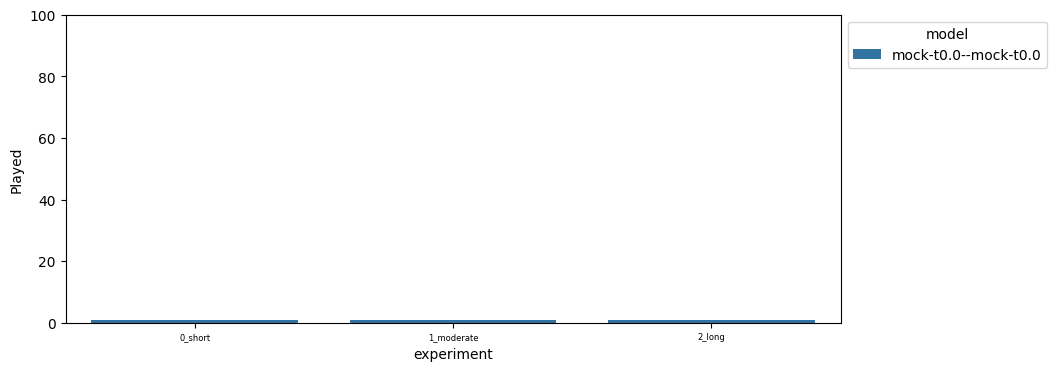

C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['experiment'] = metric_df['experiment'].astype(str)
C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)


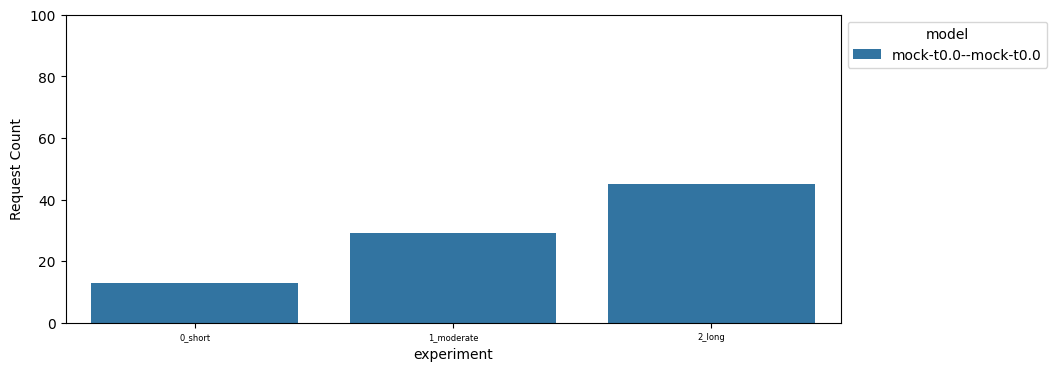

C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['experiment'] = metric_df['experiment'].astype(str)
C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)


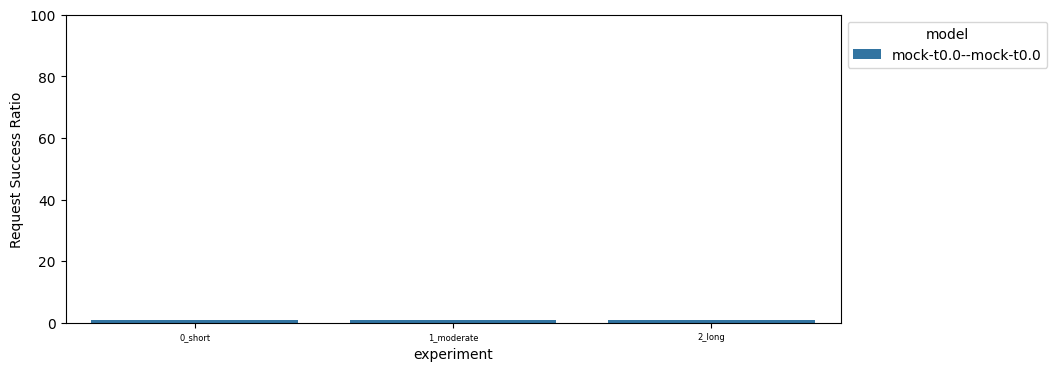

C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['experiment'] = metric_df['experiment'].astype(str)
C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)


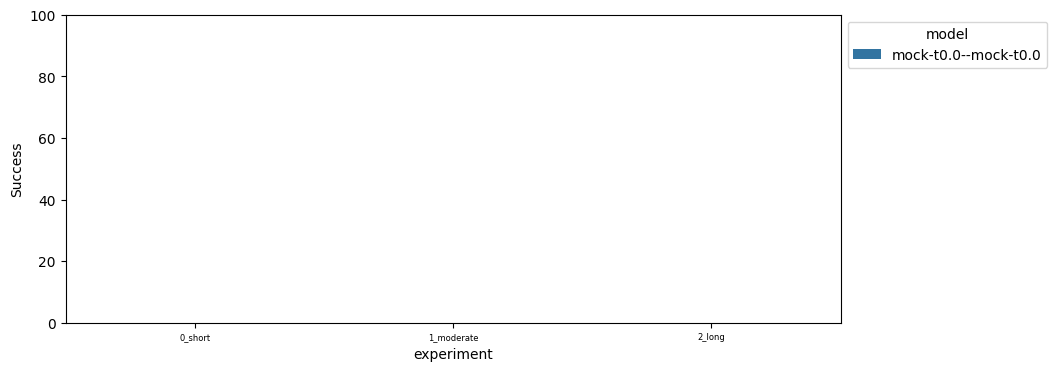

C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['experiment'] = metric_df['experiment'].astype(str)
C:\Users\heitk\AppData\Local\Temp\ipykernel_21732\4107379219.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)


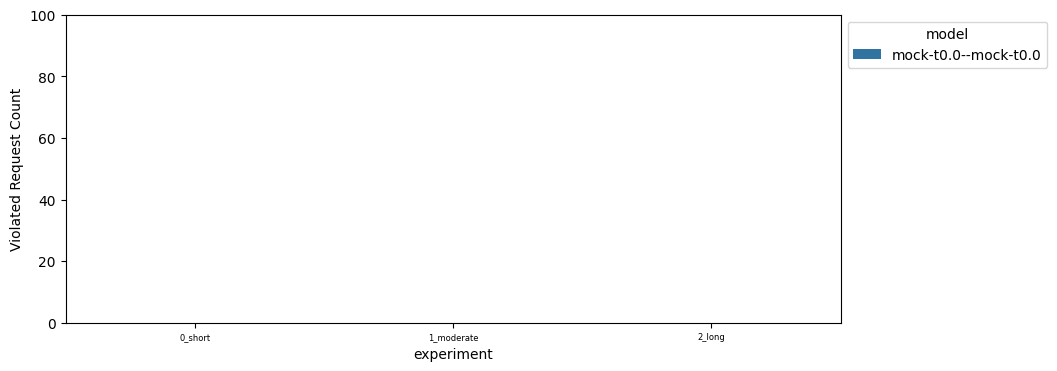

In [6]:
# Build Plots
# sorting of ouput per metric
sorted_list = list(set(game_df.metric))
sorted_list.sort()

df_list = []

for met in sorted_list:
    metric_df = game_df[game_df.metric == met]

    metric_fsc_df = game_fsc_df[game_fsc_df.metric == met] # only current model TO DO

    # clean sorting of experiments
    metric_df['experiment'] = metric_df['experiment'].astype(str)
    metric_df = metric_df.iloc[metric_df['experiment'].str.extract(r'(\d+)').astype(int).squeeze().argsort()]

    metric_fsc_df['experiment'] = metric_fsc_df['experiment'].astype(str)
    metric_fsc_df = metric_fsc_df.iloc[metric_fsc_df['experiment'].str.extract(r'(\d+)').astype(int).squeeze().argsort()]

    df_list.append(metric_fsc_df)

    # change figure size
    fig, ax = plt.subplots(figsize=(10, 4))

    # choose whats in each axis and legend
    # you can also e.g. swap y and hue, for games in legend and models in axis
    g = sns.barplot(metric_df,
                    x='experiment',
                    y='value',
                    hue='model', 
                    ax=ax)

    # customize plot details according to your needs
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))

    # customize plot according to metric
    if met.startswith('Word mover distance'):
        plt.ylim(0, 5)
    elif met.endswith('(avg)') or met.endswith('(final)'):
        plt.ylim(0,1)
    else:
        plt.ylim(0, 100)
    plt.ylabel(met)
    # reduce x axis label size
    plt.tick_params(axis='x', labelsize=6)

    # display table for each metric TO DO
    # display(metric_fsc_df[['experiment', 'model', 'value']].set_index('experiment'))

    # Concatenate all dataframes in the list into one dataframe
    combined_df = pd.concat(df_list, ignore_index=True)

    # Display the combined dataframe
    # display(combined_df[['metric', 'experiment', 'model', 'value']].set_index(['metric', 'experiment']))  # Highlighted change

    plt.show()

Choose path for the .csv with the raw scores. This is created after running ```bencheval.py```.

In [7]:
RAW_PATH = Path('../results/raw.csv')
raw_df = pd.read_csv(RAW_PATH, index_col=0)

Let's inspect the contents of ```data```:

In [8]:
raw_df

,game,model,experiment,episode,metric,value
0,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Aborted,0.0
1,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Request Count,13.0
2,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Parsed Request Count,13.0
3,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Violated Request Count,0.0
4,grounding,mock-t0.0--mock-t0.0,0_short,episode_0,Request Success Ratio,1.0
...,...,...,...,...,...,...
915,privateshared,mock-t0.0--mock-t0.0,4_letter-number,episode_5,Played,0.0
916,privateshared,mock-t0.0--mock-t0.0,4_letter-number,episode_6,Played,0.0
917,privateshared,mock-t0.0--mock-t0.0,4_letter-number,episode_7,Played,0.0
918,privateshared,mock-t0.0--mock-t0.0,4_letter-number,episode_8,Played,0.0


If we want to evaluate a single game and the results directory contained more games, we can filter the game column:

In [9]:
game_df = raw_df[raw_df.game == 'grounding']
game_fsc_df = game_df[game_df.model == 'fsc-openchat-3.5-0106-t0.0--fsc-openchat-3.5-0106-t0.0']
game_df
game_fsc_df

,game,model,experiment,episode,metric,value


## Overview tables

Get dispersion metrics over all episodes. Note that we use groupby, which will ignore NaN values, according to the documentation!

In [10]:
stats_df = build_dispersion_table(['game', 'model', 'metric'], game_df) # could also use raw_df for results for all games
stats_fsc_df = build_dispersion_table(['game', 'model', 'metric'], game_fsc_df) # could also use raw_df for results for all games
stats_df
stats_fsc_df

,,,mean,std,var,median,max,min,skew
game,model,metric,,,,,,,


Break results down by experiment:

In [11]:
detailed_stats_df = build_dispersion_table(['game', 'model', 'experiment', 'metric'], game_df) # could also use raw_df for results for all games
detailed_stats_fsc_df = build_dispersion_table(['game', 'model', 'experiment', 'metric'], game_fsc_df) # could also use raw_df for results for all games
detailed_stats_df
detailed_stats_fsc_df
detailed_stats_fsc_df.head(54)

,,,,mean,std,var,median,max,min,skew
game,model,experiment,metric,,,,,,,


To save the table, call ```to_csv```, ```to_html``` and/or ```to_latex``` (there are also other formats and customization options, check the pandas docs):

In [12]:
stats_df.to_csv('../results/stats.csv')
detailed_stats_df.to_csv('../results/detailed_stats.csv')
detailed_stats_fsc_df.to_csv('../results/detailed_stats_fsc.csv')

## Basic Plots

Plots can of course be created with ```matplotlib``` directly, but ```seaborn``` makes it very easy to work with pandas dataframes. Let's create a barplot with an overview by model and experiment:

In [13]:
# choose a metric
METRIC = 'Main Score'
metric_df = game_df[game_df.metric == METRIC].sort_values('experiment')

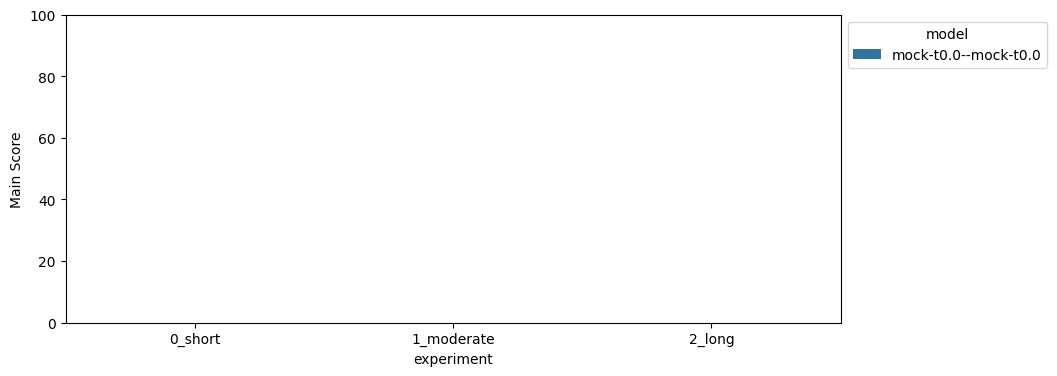

In [14]:
# change the figure size according to your needs
fig, ax = plt.subplots(figsize=(10, 4))

# choose what goes in each axis and legend according to your needs
# you can also e.g. swap y and hue, to get games in the legend and models in the axis
g = sns.barplot(metric_df,
                x='experiment',
                y='value',
                hue='model', 
                ax=ax)

# customize plot details according to your needs
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.ylim(0, 100)
plt.ylabel(METRIC)

plt.show()

## Benchmark plots

Reproducing Figure 10 in the paper. As more models or games are added, sizes must be adjusted accordingly:

In [15]:
# read the clem scores
RESULTS_PATH = Path('../results/results.csv')
clem_df = pd.read_csv(RESULTS_PATH, index_col=0)

Horizontal bar plot with player, aborted, lost:

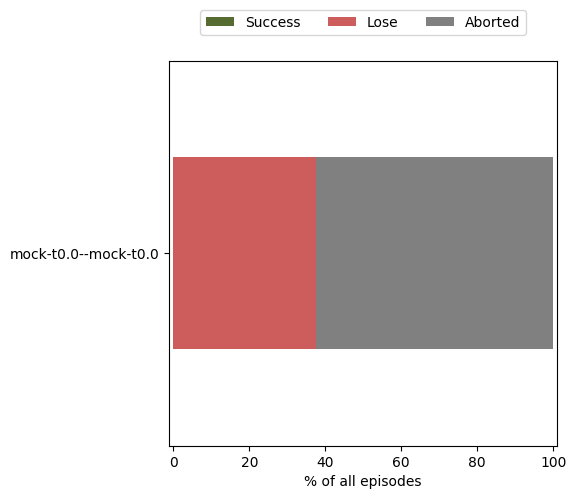

In [16]:
STACK_COLORS = ['darkolivegreen', 'indianred', 'gray']

df_aux = raw_df[raw_df.metric.isin(utils.GAMEPLAY_METRICS)]

df_aux = (df_aux.pivot(index=['game', 'model', 'experiment', 'episode'],
                       columns='metric',
                       values='value')
                .reset_index()
                .drop(columns=['game', 'experiment', 'episode'])
                .groupby('model')
                .sum()
                .sort_values(axis=1, by='metric', ascending=False))
percs = 100 * df_aux.div(df_aux.sum(axis=1), axis=0)
order = clem_df.sort_values(by='-, clemscore').index
percs = percs.reindex(order)

percs.plot(kind='barh',
           stacked=True,
           figsize=(5, 5),
           colormap=ListedColormap(STACK_COLORS))
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncols=3)
plt.xlabel('% of all episodes')
plt.xlim(-1, 101)
plt.ylabel('')
plt.show()

Bar plot with the sorted clemscores (they were not sorted in the paper):

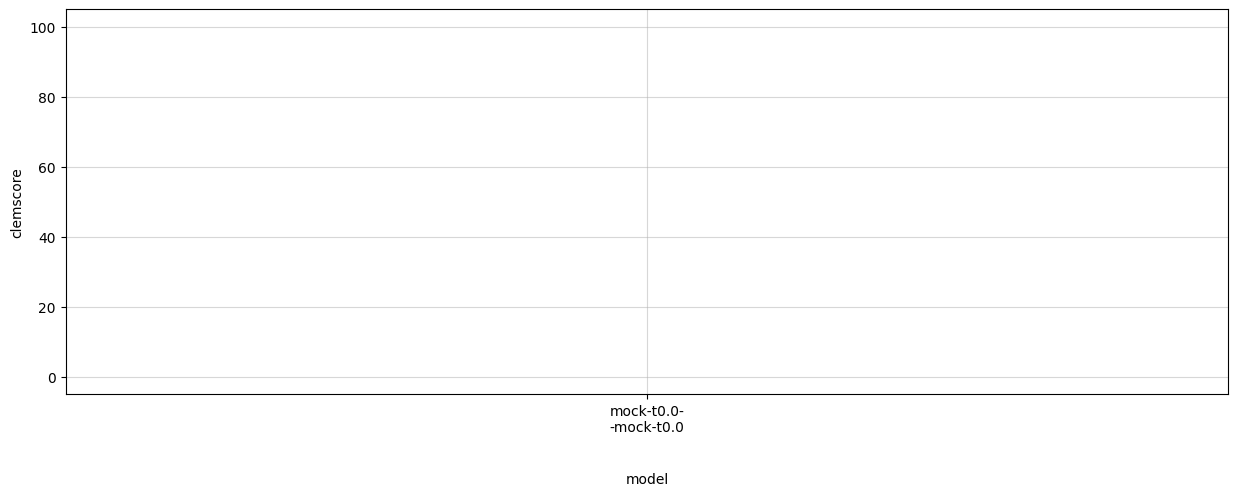

In [17]:
clem_aux = clem_df.sort_values(by='-, clemscore').reset_index(names='model')
# below is a hack to make the current names fit the plot
# ideally a dictionary with short names should be used as in the original implementation for the paper
# warning, if models have matching names up the limit, results will be wrongly merged!
clem_aux['model'] = clem_aux['model'].apply(lambda x: f'{x[:10]}\n{x[10:20]}\n{x[20:30]}\n{x[30:]}')

fig = plt.figure(figsize=(15, 5))
sns.barplot(clem_aux, x='model', y='-, clemscore', color='slategray')
plt.ylim(-5, 105)
plt.ylabel('clemscore')
plt.grid(alpha=0.5)
plt.show()

Polygons. This can get complicated if more games are added. In particular, COLUMN_ORDER must be adjusted. For more models, the number of subplots and figsize must be adjusted.

KeyError: 'grounding'

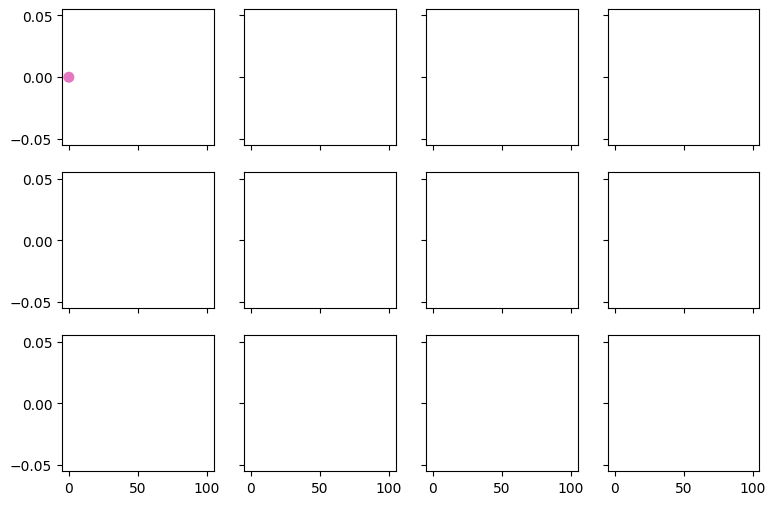

In [18]:
def ccw_sort(p):
    """Put the nodes in clockwise order."""
    # from https://stackoverflow.com/a/44143444 by user ImportanceOfBeingEarnest
    p = np.array(p)
    mean = np.mean(p, axis=0)
    d = p - mean
    s = np.arctan2(d[:, 0], d[:, 1])
    return p[np.argsort(s), :]


fig, ax_list = plt.subplots(3, 4, figsize=(9, 6), sharey=True, sharex=True)
axs = ax_list.flatten()

for n, (model, model_df) in enumerate(raw_df.groupby('model')):
    rows = model_df.metric.isin(utils.MAIN_METRICS)
    df_aux = model_df[rows]
    df_aux = (df_aux.pivot(index=['game', 'experiment', 'episode'],
                            columns='metric',
                            values='value')
                    .reset_index())
    df_aux = df_aux.drop(['episode'], axis=1)

    # create the x and y coordinates for each game
    dots = []
    for game, game_df in df_aux.groupby('game'):
        overall_means = (game_df.mean(numeric_only=True)
                                .fillna(0))
        # replace missing score by 0 when all aborted
        played = overall_means[clemmetrics.METRIC_PLAYED] * 100
        score = overall_means[clemmetrics.BENCH_SCORE]
        dots.append((game, played, score))
    labels, played, scores = zip(*dots)
    # put them in a good order for the polygon
    edges = ccw_sort(list(zip(played, scores)))

    # create the polygon and draw it
    polygon = Polygon(edges, facecolor='lightgray')
    axs[n].add_patch(polygon)

    legend = True if n == 10 else False
    g = sns.scatterplot(x=played,
                        y=scores,
                        hue=labels,
                        style=labels,
                        hue_order=utils.COLUMN_ORDER[1:],
                        style_order=utils.COLUMN_ORDER[1:],
                        s=80,
                        ax=axs[n],
                        legend=legend)
    axs[n].set_xlim(-5, 105)
    axs[n].set_ylim(-5, 105)
    axs[n].set_ylabel('avr. quality')
    axs[n].set_xlabel('% played')
    axs[n].set_title(model, fontsize=8)

fig.legend(loc='lower right', bbox_to_anchor=(0.98, 0.08))
axs[10].legend().set_visible(False)
fig.delaxes(axs[11])
plt.tight_layout()
plt.show()